# Compare volume integrals of KDUQ potentials

Volume integrals are a useful way to gain intuition about the relative importance of different terms at different energies.

For a spherical potential term $V(r;E)$, we define

\begin{equation}
    \frac{J_V(E)}{ A} \equiv \frac{4\pi}{A} \int_0^\infty V(r;E) r^2 dr
\end{equation}

In [1]:
import numpy as np
from tqdm import tqdm

In [2]:
from matplotlib import pyplot as plt

In [3]:
from jitr.reactions import ElasticReaction

In [4]:
from jitr.optical_potentials import kduq

In [5]:
from jitr.optical_potentials.potential_forms import (
    thomas_volume_integral,
    woods_saxon_prime_volume_integral,
    woods_saxon_volume_integral,
)
from jitr.utils.constants import WAVENUMBER_PION

In [6]:
neutron = (1, 0)
proton = (1, 1)

In [7]:
target = (24, 12)
projectile = proton
energy_lab = np.linspace(10, 250, 100)
rxn = ElasticReaction(target=target, projectile=projectile)

In [8]:
kduq_samples = kduq.get_samples(projectile)

In [9]:
kinematics = rxn.kinematics(energy_lab)

In [10]:
r = np.linspace(0.1, 10, 1000)
kduq_v_central = np.zeros(
    (kduq.NUM_POSTERIOR_SAMPLES, energy_lab.size, r.size), dtype=complex
)
kduq_v_so = np.zeros(
    (kduq.NUM_POSTERIOR_SAMPLES, energy_lab.size, r.size), dtype=complex
)
central_volume_integral_analytic = np.zeros(
    (kduq.NUM_POSTERIOR_SAMPLES, energy_lab.size), dtype=complex
)

so_volume_integral_analytic = np.zeros(
    (kduq.NUM_POSTERIOR_SAMPLES, energy_lab.size), dtype=complex
)

for i, kduq_sample in enumerate(tqdm(kduq_samples)):
    for j, E in enumerate(kinematics.Elab):
        cent, so, coul = kduq.calculate_params(projectile, target, E, *kduq_sample)
        kduq_v_central[i, j, :] = kduq.central(r, *cent)
        kduq_v_so[i, j, :] = kduq.spin_orbit(r, *so)

        Vv, Rv, av, Wv, Rw, aw, Wd, Rd, ad = cent
        jv = -woods_saxon_volume_integral(Vv, Rv, av)
        jw = -woods_saxon_volume_integral(
            Wv, Rw, aw
        ) - woods_saxon_prime_volume_integral(Wd, Rd, ad)

        central_volume_integral_analytic[i, j] = jv + 1j * jw

        Vso, Rso, aso, Wso, Rwso, awso = so
        so_volume_integral_analytic[i, j] = -thomas_volume_integral(
            Vso, Rso, aso
        ) - 1j * thomas_volume_integral(Wso, Rwso, awso)

 96%|████████████████████████████████████████████████████████████████████████████▏  | 401/416 [00:10<00:00, 40.37it/s]/home/kyle/umich/jitr/src/jitr/optical_potentials/kduq.py:467: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))
100%|███████████████████████████████████████████████████████████████████████████████| 416/416 [00:11<00:00, 36.51it/s]


In [11]:
A = target[0]
central_volume_integral = (
    (4 * np.pi) / A * np.trapezoid(kduq_v_central * r**2, r, axis=-1)
)
so_volume_integral = (4 * np.pi) / A * np.trapezoid(kduq_v_so * r**2, r, axis=-1)

In [12]:
central_volume_integral_analytic *= 1 / A
so_volume_integral_analytic *= (1 / WAVENUMBER_PION) ** 2 / A

In [13]:
def get_ci(x):
    return np.percentile(x.real, [16, 50, 84], axis=0) + 1j * np.percentile(
        x.imag, [5, 50, 95], axis=0
    )

In [14]:
np.testing.assert_allclose(
    central_volume_integral_analytic, central_volume_integral, atol=0.2
)

Text(0.5, 1.0, '$^{24} \\rm{Mg}(p,el)$')

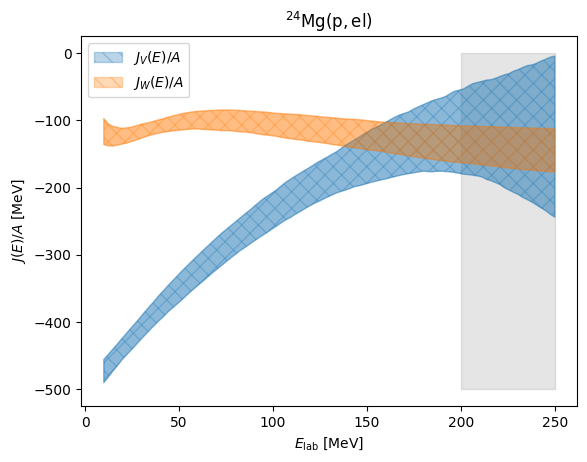

In [15]:
l, m, u = get_ci(central_volume_integral)
plt.fill_between(
    energy_lab,
    l.real,
    u.real,
    alpha=0.3,
    color="tab:blue",
    hatch=r"\\",
    label=r"$J_V(E)/A$",
)
plt.fill_between(
    energy_lab,
    l.imag,
    u.imag,
    alpha=0.3,
    color="tab:orange",
    hatch=r"\\",
    label=r"$J_W(E)/A$",
)

l, m, u = get_ci(central_volume_integral_analytic)
plt.fill_between(energy_lab, l.real, u.real, alpha=0.3, color="tab:blue", hatch="//")
plt.fill_between(energy_lab, l.imag, u.imag, alpha=0.3, color="tab:orange", hatch="//")

plt.fill_between(
    [200, 250],
    [-500, -500],
    [
        0,
        0,
    ],
    color="k",
    alpha=0.1,
    zorder=-1,
)

plt.legend()
plt.xlabel(r"$E_{\text{lab}}$ [MeV]")
plt.ylabel(r"$J(E)/A$ [MeV]")
plt.title(f"${rxn.reaction_latex}$")

In [16]:
np.testing.assert_allclose(so_volume_integral_analytic, so_volume_integral, atol=0.01)

Text(0.5, 1.0, '$^{24} \\rm{Mg}(p,el)$')

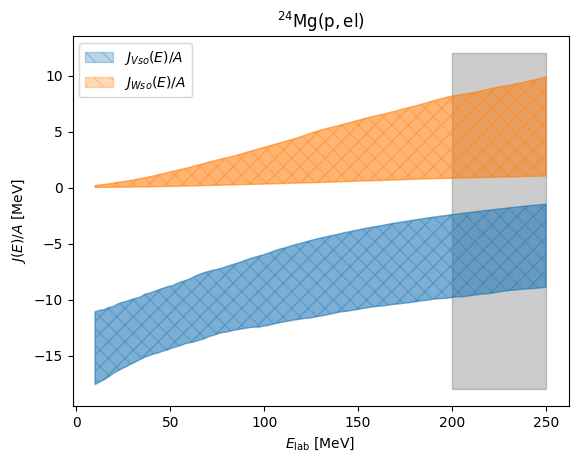

In [17]:
l, m, u = get_ci(so_volume_integral)
plt.fill_between(
    energy_lab,
    l.real,
    u.real,
    alpha=0.3,
    color="tab:blue",
    hatch=r"\\",
    label=r"$J_{Vso}(E)/A$",
)
plt.fill_between(
    energy_lab,
    l.imag,
    u.imag,
    alpha=0.3,
    color="tab:orange",
    hatch=r"\\",
    label=r"$J_{Wso}(E)/A$",
)

l, m, u = get_ci(so_volume_integral_analytic)
plt.fill_between(energy_lab, l.real, u.real, alpha=0.4, color="tab:blue", hatch="//")
plt.fill_between(energy_lab, l.imag, u.imag, alpha=0.4, color="tab:orange", hatch="//")
plt.fill_between(
    [200, 250],
    [-18, -18],
    [
        12,
        12,
    ],
    color="k",
    alpha=0.2,
    zorder=-1,
)


plt.legend()
plt.xlabel(r"$E_{\text{lab}}$ [MeV]")
plt.ylabel(r"$J(E)/A$ [MeV]")
plt.title(f"${rxn.reaction_latex}$")